In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV, KFold

In [2]:
waka_dragon_df = pd.read_csv("data/waka_dragon_merged.csv")
mX_df = waka_dragon_df.loc[:, 'MW':]

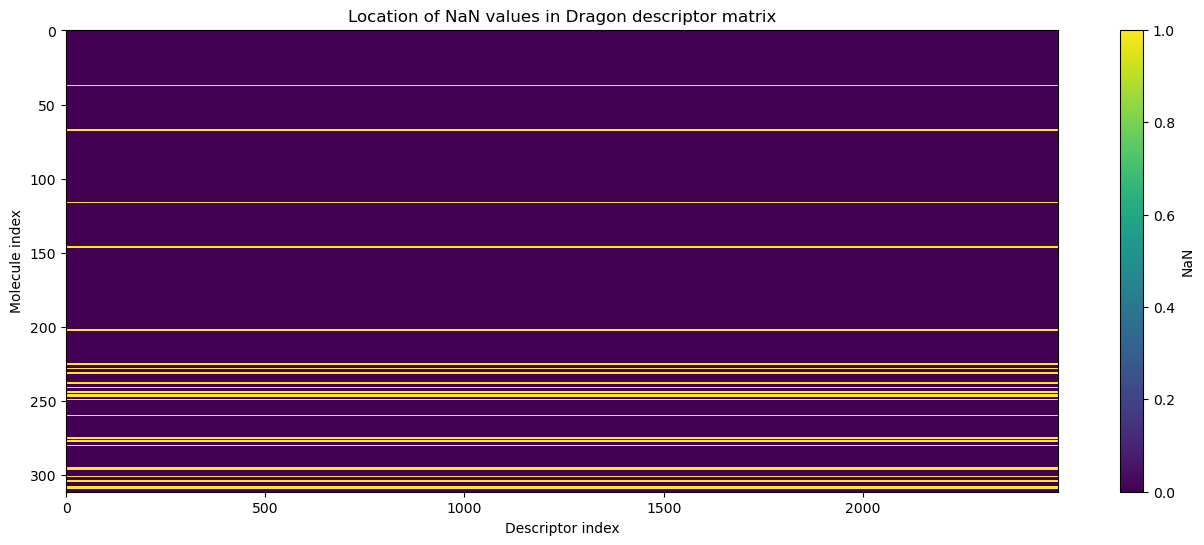

In [3]:
plt.figure(figsize=(16, 6))

plt.imshow(
    mX_df.isna(),
    aspect='auto',
    interpolation='none'
)

plt.xlabel('Descriptor index')
plt.ylabel('Molecule index')
plt.title('Location of NaN values in Dragon descriptor matrix')

plt.colorbar(label='NaN')
plt.show()

In [4]:
valid_mask = ~mX_df.isna().all(axis=1)
valid_mask

0       True
1       True
2       True
3       True
4       True
       ...  
307     True
308    False
309    False
310     True
311     True
Length: 312, dtype: bool

In [5]:
mX_df = waka_dragon_df.loc[valid_mask, 'MW':]

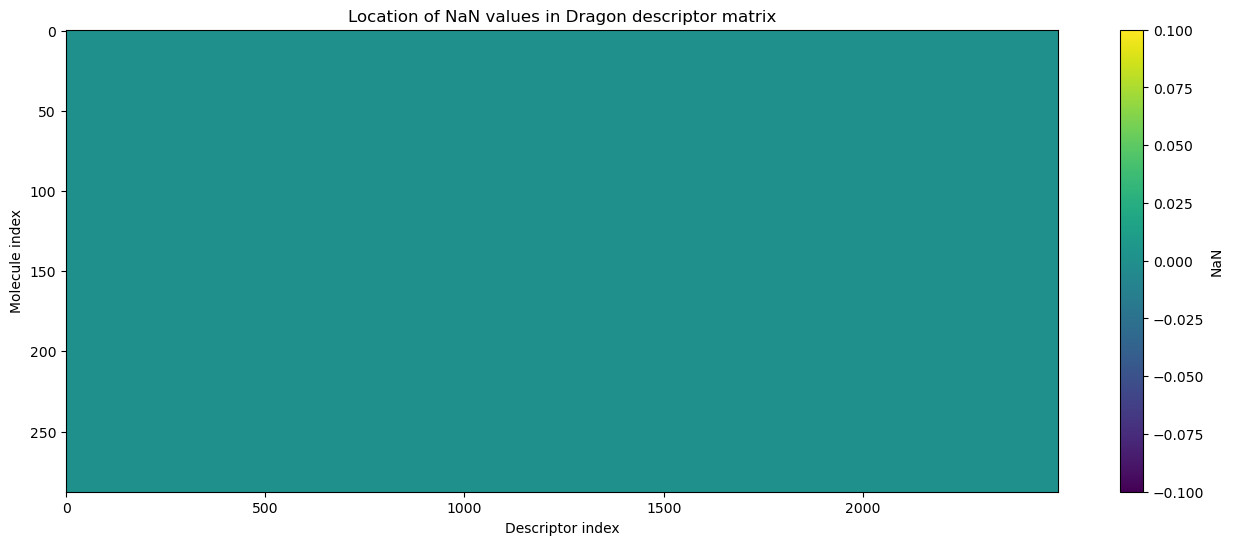

In [6]:
plt.figure(figsize=(16, 6))

plt.imshow(
    mX_df.isna(),
    aspect='auto',
    interpolation='none'
)

plt.xlabel('Descriptor index')
plt.ylabel('Molecule index')
plt.title('Location of NaN values in Dragon descriptor matrix')

plt.colorbar(label='NaN')
plt.show()

In [7]:
waka_dragon_df = waka_dragon_df.loc[valid_mask,:]
waka_dragon_df

,CID,CAS,Name,Imax,Ci,Di_x,intensity_class,MW,AMW,Sv,...,VvdwMG,VvdwZAZ,PDI,BLTF96,BLTD48,BLTA96,nCIR,ZM1,R8u_,nRCOSR
0,179,513-86-0,acetoin,49.69,0.90,0.76,1,88.12,6.294,7.537,...,54.205,92.70,0.717,-1.20,-1.11,-1.00,0.0,22.0,0.000,0.0
1,240,100-52-7,benzaldehyde,62.02,1.23,0.69,1,106.13,7.581,9.295,...,62.810,104.63,0.919,-2.89,-3.00,-3.00,1.0,34.0,0.000,0.0
2,244,100-51-6,benzyl alcohol,30.28,1.49,0.33,0,108.15,6.759,9.822,...,65.737,107.27,0.866,-2.74,-2.83,-2.82,1.0,34.0,0.000,0.0
3,323,91-64-5,coumarin,26.79,0.68,0.77,0,146.15,8.597,12.010,...,75.670,133.02,0.984,-3.32,-3.47,-3.49,3.0,56.0,0.000,0.0
4,326,122-03-2,cumin aldehyde,49.53,1.29,0.47,1,148.22,6.444,13.876,...,91.587,156.53,0.898,-3.70,-3.91,-3.95,1.0,50.0,0.033,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,15461361,67883-79-8,cis-3-hexenyl tiglate,44.85,0.01,0.63,1,182.29,5.880,17.171,...,115.496,208.52,0.847,-3.74,-3.95,-4.00,0.0,50.0,0.036,0.0
306,16063567,141773-73-1,helvetolide,7.05,-0.75,0.22,0,284.49,5.471,27.573,...,175.508,314.03,0.838,-4.20,-4.46,-4.54,1.0,98.0,0.017,0.0
307,16070752,117933-89-8,karanal,48.88,-1.32,0.50,1,266.47,5.438,26.332,...,164.119,292.88,0.873,-4.57,-4.87,-4.97,2.0,98.0,0.016,0.0
310,44153588,113889-23-9,tricyclodecenyl butyrate,24.15,-0.51,0.11,0,220.34,6.121,20.698,...,125.021,225.98,0.930,-4.19,-4.44,-4.52,6.0,88.0,0.021,0.0


In [8]:
vY_Imax = waka_dragon_df['Imax']

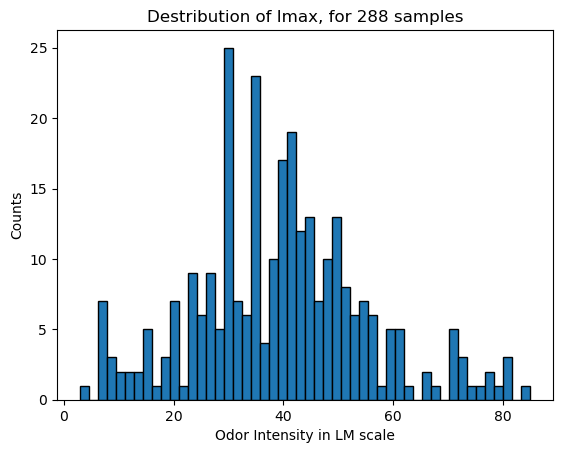

In [65]:
import matplotlib.pyplot as plt
plt.hist(vY_Imax, bins = 50, edgecolor='k')
plt.title(f"Destribution of Imax, for {len(vY_Imax)} samples")
plt.xlabel("Odor Intensity in LM scale")
plt.ylabel("Counts")
plt.show()

In [10]:
#first we remove features with zero variance
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0) #object 

mX1 = vt.fit_transform(mX_df) #returns NDArray

# mX1_df becomes the updated feature matrix
mX1_df = pd.DataFrame(
    mX1,
    columns=mX_df.columns[vt.get_support()],
    index=mX_df.index
)

print(mX1_df.shape)

(288, 2484)


In [11]:
# correlations matrix
corr_matrix = mX1_df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > 0.95) # May be the correlation threshold should be lower
]

print(f"Descriptors to remove: {len(to_drop)}")

Descriptors to remove: 1650


In [12]:
# Dropping of high correlated descriptors
mX2_df = mX1_df.drop(columns=to_drop)
print(mX2_df.shape)

(288, 834)


In [13]:
n_cols_with_nan = mX2_df.isna().any(axis=0).sum()

print(f"Columns containing NaN: {n_cols_with_nan}")
print(f"Total columns: {mX2_df.shape[1]}")

Columns containing NaN: 0
Total columns: 834


In [66]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [67]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import KFold, cross_val_predict

dummy_reg = DummyRegressor(strategy='mean')
y_pred_dummy = cross_val_predict(
    dummy_reg,
    mX2_df,
    vY_Imax,
    cv=cv
)
mae_rdkit_dummy = mean_absolute_error(vY_Imax, y_pred_dummy)
r2_rdkit_dummy = r2_score(vY_Imax, y_pred_dummy)

print(f"MAE = {mae_rdkit_dummy:.3f}")
print(f"R²  = {r2_rdkit_dummy:.3f}")

MAE = 12.137
R²  = -0.008


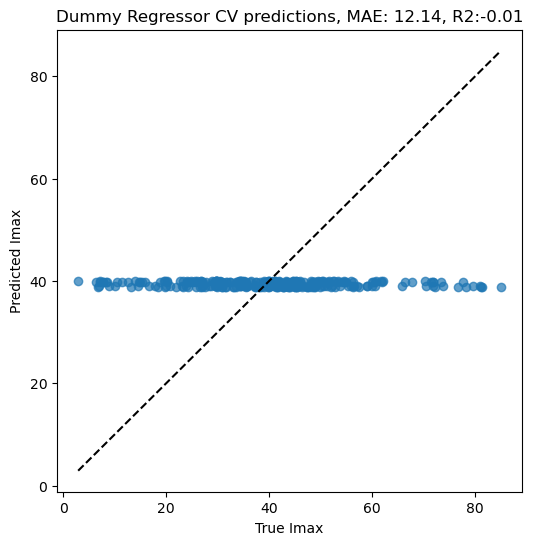

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(vY_Imax, y_pred_dummy, alpha=0.7)

plt.plot(
    [vY_Imax.min(), vY_Imax.max()],
    [vY_Imax.min(), vY_Imax.max()],
    '--k'
)

plt.xlabel("True Imax")
plt.ylabel("Predicted Imax")
plt.title(f"Dummy Regressor CV predictions, MAE: {mae_rdkit_dummy:.2f}, R2:{r2_rdkit_dummy:.2f}")

plt.show()

In [14]:
xgb_reg = XGBRegressor(
    objective="reg:absoluteerror",
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_reg.fit(mX2_df, vY_Imax)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:absoluteerror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [15]:
importance = pd.Series(
    xgb_reg.feature_importances_,
    index= mX2_df.columns
).sort_values(ascending=False)

importance.head(60)

ATS6m             0.004428
Vindex            0.004106
RDF015s           0.003886
MPC08             0.003784
SpMaxA_AEA_dm_    0.003617
Eig07_AEA_dm_     0.003211
RDF065s           0.003096
SpMax6_Bh_s_      0.002788
ATS5m             0.002751
HATS0v            0.002689
SpPosA_RG         0.002679
GGI6              0.002592
Mor08m            0.002580
VE3_RG            0.002573
VE2_B_m_          0.002526
Eta_betaS_A       0.002451
SM11_AEA_bo_      0.002432
RDF010s           0.002394
H2v               0.002371
Mor03v            0.002337
SpMax7_Bh_s_      0.002310
RDF050m           0.002307
Mor11u            0.002264
ChiA_B_m_         0.002249
VE3sign_B_v_      0.002246
G2m               0.002230
SM12_AEA_bo_      0.002218
R6u               0.002209
HATS8m            0.002208
ATSC8e            0.002207
TDB01m            0.002206
SpMax2_Bh_s_      0.002196
RDF025s           0.002186
Mor05m            0.002151
ZM1Mad            0.002126
HGM               0.002105
TDB10u            0.002098
A

In [16]:
top60_reg_features = importance.index[:60]
top60_reg_features

Index(['ATS6m', 'Vindex', 'RDF015s', 'MPC08', 'SpMaxA_AEA_dm_',
       'Eig07_AEA_dm_', 'RDF065s', 'SpMax6_Bh_s_', 'ATS5m', 'HATS0v',
       'SpPosA_RG', 'GGI6', 'Mor08m', 'VE3_RG', 'VE2_B_m_', 'Eta_betaS_A',
       'SM11_AEA_bo_', 'RDF010s', 'H2v', 'Mor03v', 'SpMax7_Bh_s_', 'RDF050m',
       'Mor11u', 'ChiA_B_m_', 'VE3sign_B_v_', 'G2m', 'SM12_AEA_bo_', 'R6u',
       'HATS8m', 'ATSC8e', 'TDB01m', 'SpMax2_Bh_s_', 'RDF025s', 'Mor05m',
       'ZM1Mad', 'HGM', 'TDB10u', 'ATSC6m', 'Mor11v', 'Mor05v', 'GGI3', 'Am',
       'Mor07m', 'VE1sign_B_v_', 'R5s', 'H3u', 'AVS_B_s_', 'SpMax6_Bh_m_',
       'SM09_AEA_dm_', 'H6s', 'Mor04v', 'MATS1e', 'SpMin1_Bh_s_', 'RDF025u',
       'Mor29u', 'JGI2', 'H7s', 'ATSC1e', 'MATS1v', 'Mor13m'],
      dtype='str')

In [17]:
X_top60 = mX2_df[top60_reg_features].copy()
print(X_top60.shape)

(288, 60)


In [18]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
scores = cross_val_score(
    xgb_reg,
    X_top60,
    vY_Imax,
    scoring="neg_mean_absolute_error",
    cv=cv
)
print("CV MAE:", -scores.mean())
print("STD:", scores.std())

CV MAE: 7.731994859061959
STD: 0.5170310748267408


In [19]:
importance = pd.Series(
    xgb_reg.feature_importances_,
    index=mX2_df.columns
).sort_values(ascending=False)

In [20]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score

results = []

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for n_features in range(10, 115, 5):

    top_features = importance.index[:n_features]

    X_subset = mX2_df[top_features]

    model = XGBRegressor(
        objective='reg:absoluteerror',
        n_estimators=500,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    y_pred = cross_val_predict(
        model,
        X_subset,
        vY_Imax,
        cv=cv
    )

    mae = mean_absolute_error(vY_Imax, y_pred)
    r2 = r2_score(vY_Imax, y_pred)

    results.append({
        'n_features': n_features,
        'MAE': mae,
        'R2': r2
    })

results_df = pd.DataFrame(results)

results_df

,n_features,MAE,R2
0,10,8.592958,0.514625
1,15,8.117381,0.563993
2,20,8.003454,0.578295
3,25,8.055779,0.574167
4,30,7.755052,0.602042
5,35,7.788903,0.596022
6,40,7.611475,0.606635
7,45,7.748365,0.595917
8,50,7.835863,0.586602
9,55,7.618073,0.607829


In [21]:
results_df.sort_values('MAE')

,n_features,MAE,R2
13,75,7.418400,0.623213
16,90,7.470724,0.618892
19,105,7.481705,0.613680
12,70,7.496842,0.616483
18,100,7.525020,0.608560
15,85,7.526849,0.615403
14,80,7.539818,0.613261
20,110,7.569502,0.609868
17,95,7.608175,0.614659
6,40,7.611475,0.606635


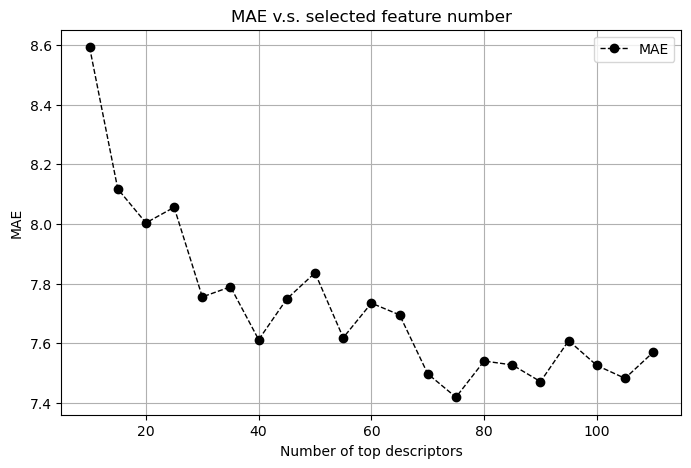

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    results_df['n_features'],
    results_df['MAE'],
    marker='o',
    label='MAE',
    linestyle = '--', color = 'k', lw=1
)
plt.title("MAE v.s. selected feature number")
plt.xlabel('Number of top descriptors')
plt.ylabel('MAE')
plt.grid(True)
plt.legend()

plt.show()

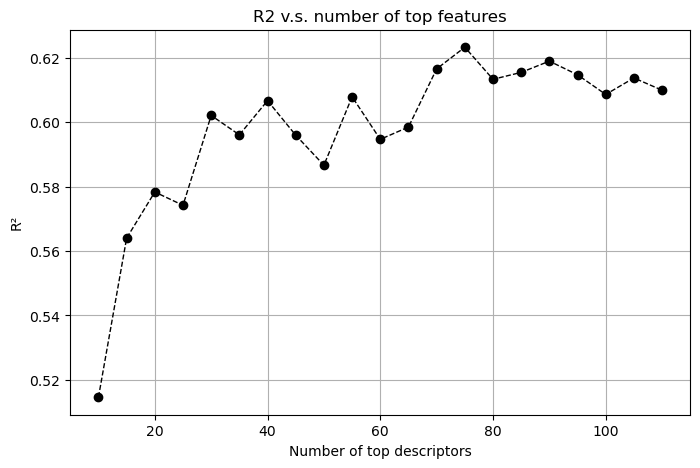

In [23]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df['n_features'],
    results_df['R2'],
    marker='o',
    linestyle = '--', color = 'k', lw=1
)
plt.title('R2 v.s. number of top features')
plt.xlabel('Number of top descriptors')
plt.ylabel('R²')
plt.grid(True)

plt.show()

In [24]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score

results = []

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for n_features in range(60, 101, 1):

    top_features = importance.index[:n_features]

    X_subset = mX2_df[top_features]

    model = XGBRegressor(
        objective='reg:absoluteerror',
        n_estimators=500,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    y_pred = cross_val_predict(
        model,
        X_subset,
        vY_Imax,
        cv=cv
    )

    mae = mean_absolute_error(vY_Imax, y_pred)
    r2 = r2_score(vY_Imax, y_pred)

    results.append({
        'n_features': n_features,
        'MAE': mae,
        'R2': r2
    })

results_df = pd.DataFrame(results)

results_df

,n_features,MAE,R2
0,60,7.734173,0.594628
1,61,7.623974,0.609450
2,62,7.638765,0.605556
3,63,7.595056,0.604946
4,64,7.611017,0.609802
5,65,7.694670,0.598449
6,66,7.643836,0.604867
7,67,7.605627,0.611609
8,68,7.512469,0.612409
9,69,7.610768,0.608124


In [25]:
results_df.sort_values('MAE')

,n_features,MAE,R2
11,71,7.384377,0.635358
14,74,7.414732,0.631625
15,75,7.418400,0.623213
37,97,7.426136,0.626998
18,78,7.432919,0.619904
19,79,7.433243,0.628833
13,73,7.435306,0.624355
23,83,7.455426,0.619200
34,94,7.456403,0.620659
17,77,7.456715,0.619404


In [26]:
# Fix the selected feature set
top71 = importance.index[:71]
X71 = mX2_df[top71].copy()

print(X71.shape)
print(top71)

(288, 71)
Index(['ATS6m', 'Vindex', 'RDF015s', 'MPC08', 'SpMaxA_AEA_dm_',
       'Eig07_AEA_dm_', 'RDF065s', 'SpMax6_Bh_s_', 'ATS5m', 'HATS0v',
       'SpPosA_RG', 'GGI6', 'Mor08m', 'VE3_RG', 'VE2_B_m_', 'Eta_betaS_A',
       'SM11_AEA_bo_', 'RDF010s', 'H2v', 'Mor03v', 'SpMax7_Bh_s_', 'RDF050m',
       'Mor11u', 'ChiA_B_m_', 'VE3sign_B_v_', 'G2m', 'SM12_AEA_bo_', 'R6u',
       'HATS8m', 'ATSC8e', 'TDB01m', 'SpMax2_Bh_s_', 'RDF025s', 'Mor05m',
       'ZM1Mad', 'HGM', 'TDB10u', 'ATSC6m', 'Mor11v', 'Mor05v', 'GGI3', 'Am',
       'Mor07m', 'VE1sign_B_v_', 'R5s', 'H3u', 'AVS_B_s_', 'SpMax6_Bh_m_',
       'SM09_AEA_dm_', 'H6s', 'Mor04v', 'MATS1e', 'SpMin1_Bh_s_', 'RDF025u',
       'Mor29u', 'JGI2', 'H7s', 'ATSC1e', 'MATS1v', 'Mor13m', 'HATS0p', 'VAR',
       'R6v', 'TDB06m', 'Gm', 'RDF060m', 'SsOH', 'Mor11p', 'Mor03s', 'Mor10s',
       'Mor32v'],
      dtype='str')


In [51]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb_base = XGBRegressor(
    objective="reg:absoluteerror",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [300, 500, 800],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.03, 0.05],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}

grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X71, vY_Imax)

print("Best CV MAE:", -grid.best_score_)
print("Best params:")
print(grid.best_params_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best CV MAE: 7.381770465306204
Best params:
{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}


Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best CV MAE: 7.381770465306204
Best params:
{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}

In [27]:
best_xgb = XGBRegressor(
    objective='reg:absoluteerror',
    colsample_bytree=1.0,
    learning_rate=0.05,
    max_depth=4,
    n_estimators=300,
    subsample=0.8,
    random_state=42
)

In [69]:
from sklearn.model_selection import cross_val_predict

y_pred_71 = cross_val_predict(
    best_xgb,
    X71,
    vY_Imax,
    cv=cv,
    n_jobs=-1
)

In [70]:
from sklearn.metrics import mean_absolute_error, r2_score

mae_71 = mean_absolute_error(vY_Imax, y_pred_71)
r2_71 = r2_score(vY_Imax, y_pred_71)

print(f"MAE = {mae_71:.3f}")
print(f"R²  = {r2_71:.3f}")

MAE = 7.385
R²  = 0.625


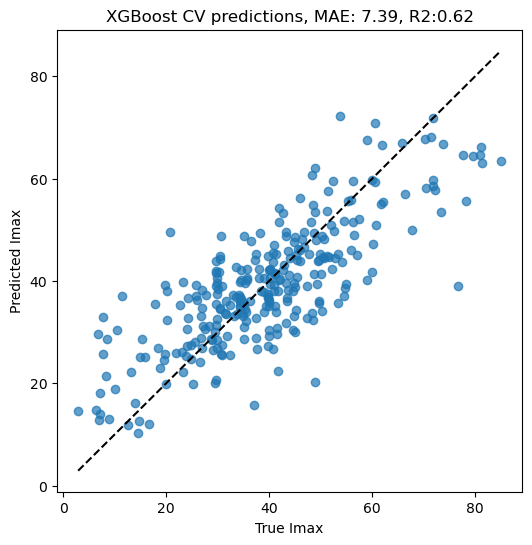

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(vY_Imax, y_pred_71, alpha=0.7)

plt.plot(
    [vY_Imax.min(), vY_Imax.max()],
    [vY_Imax.min(), vY_Imax.max()],
    '--k'
)

plt.xlabel("True Imax")
plt.ylabel("Predicted Imax")
plt.title(f"XGBoost CV predictions, MAE: {mae_71:.2f}, R2:{r2_71:.2f}")

plt.show()

In [31]:
log_vp_df = pd.read_csv('data/waka_with_imputed_vp.csv')
waka_dragon_df['CID']

0           179
1           240
2           244
3           323
4           326
         ...   
305    15461361
306    16063567
307    16070752
310    44153588
311    57353762
Name: CID, Length: 288, dtype: int64

In [176]:
X71.shape

(288, 71)

In [32]:
log_vp_df = waka_dragon_df[['CID']].merge(
    log_vp_df,
    on='CID',
    how='left'
)
log_vp_df

,CID,Name,log_vp,vp
0,179,acetoin,-0.163905,0.685638
1,240,benzaldehyde,-0.001051,0.997582
2,244,benzyl alcohol,-1.004329,0.099008
3,323,coumarin,-3.008774,0.000980
4,326,cumin aldehyde,-1.254028,0.055715
...,...,...,...,...
283,15461361,cis-3-hexenyl tiglate,-2.191580,0.006433
284,16063567,helvetolide,-4.065334,0.000086
285,16070752,karanal,-3.410876,0.000388
286,44153588,tricyclodecenyl butyrate,-3.239050,0.000577


In [33]:
# On 25.06 I rerun vp inputed 
X72 = pd.concat(
    [X71.reset_index(drop=True),
     log_vp_df['log_vp'].reset_index(drop=True)],
    axis=1
)

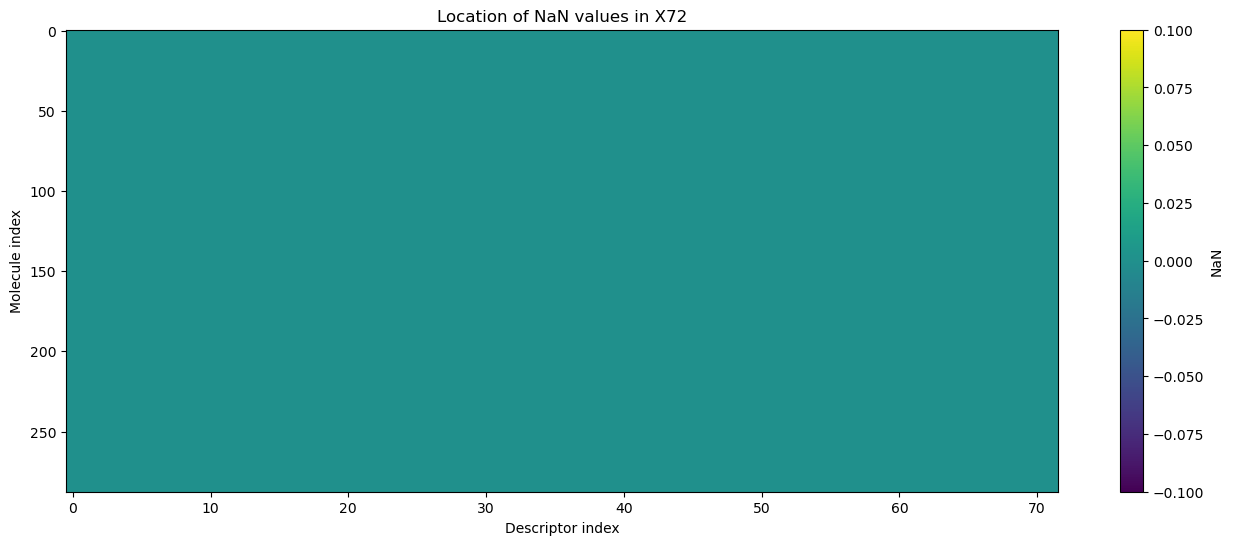

In [34]:
plt.figure(figsize=(16, 6))

plt.imshow(
    X72.isna(),
    aspect='auto',
    interpolation='none'
)

plt.xlabel('Descriptor index')
plt.ylabel('Molecule index')
plt.title('Location of NaN values in X72')

plt.colorbar(label='NaN')
plt.show()

In [35]:
y_pred_72 = cross_val_predict(
    best_xgb,
    X72,
    vY_Imax,
    cv=cv
)

In [36]:
from sklearn.metrics import mean_absolute_error, r2_score

mae_72 = mean_absolute_error(vY_Imax, y_pred_72)
r2_72 = r2_score(vY_Imax, y_pred_72)

print(f"MAE = {mae_72:.3f}")
print(f"R²  = {r2_72:.3f}")

MAE = 7.694
R²  = 0.606


In [37]:
# now we try to add boiling point
bp_df = pd.read_csv('data/waka_with_imputed_bp.csv')
merged_waka_bp = pd.merge(
    waka_dragon_df[['CID', 'Name']],
    bp_df[['CID', 'bp_value']],
    on='CID',
    how='left'
)
X73 = pd.concat(
    [X72.reset_index(drop=True),
     merged_waka_bp['bp_value'].reset_index(drop=True)],
    axis=1
)
X73

,ATS6m,Vindex,RDF015s,MPC08,SpMaxA_AEA_dm_,Eig07_AEA_dm_,RDF065s,SpMax6_Bh_s_,ATS5m,HATS0v,...,TDB06m,Gm,RDF060m,SsOH,Mor11p,Mor03s,Mor10s,Mor32v,log_vp,bp_value
0,0.000,1.088,12.111,0.000,0.742,0.000,0.000,1.132,0.081,0.144,...,0.000,0.217,0.000,8.280,-0.094,-8.218,-2.686,-0.023,-0.163905,147.500000
1,0.113,0.573,10.236,0.000,0.373,-1.505,0.000,1.992,1.013,0.089,...,0.008,0.351,0.051,0.000,0.208,-2.957,-1.108,-0.150,-0.001051,178.889000
2,0.202,0.573,14.909,0.000,0.344,-1.350,0.000,1.992,1.110,0.141,...,0.010,0.213,0.113,8.538,0.339,-2.495,-0.503,-0.156,-1.004329,205.500000
3,1.040,0.431,17.597,2.944,0.302,-0.382,0.049,3.141,1.885,0.092,...,0.084,0.338,1.033,0.000,0.123,-7.225,0.012,-0.144,-3.008774,299.000000
4,1.627,0.487,16.550,0.000,0.277,-1.000,23.115,3.416,1.974,0.108,...,0.102,0.348,0.055,0.000,0.114,1.359,0.019,-0.108,-1.254028,153.796459
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,2.380,0.597,25.538,1.792,0.306,0.179,18.475,3.685,2.524,0.072,...,0.118,0.171,0.848,0.000,-0.228,-8.763,-0.412,0.076,-2.191580,180.759099
284,3.338,0.390,40.240,3.135,0.185,1.118,99.222,3.895,3.565,0.052,...,0.118,0.174,7.330,0.000,-0.416,-30.526,1.995,-0.101,-4.065334,208.888083
285,3.017,0.313,43.836,3.932,0.178,1.451,56.211,3.841,3.287,0.047,...,0.099,0.170,3.307,0.000,-0.414,-14.899,1.448,0.069,-3.410876,301.520307
286,2.815,0.290,31.247,4.290,0.208,1.035,22.376,3.271,2.954,0.068,...,0.153,0.176,3.147,0.000,-0.435,-22.239,0.678,-0.156,-3.239050,297.571641


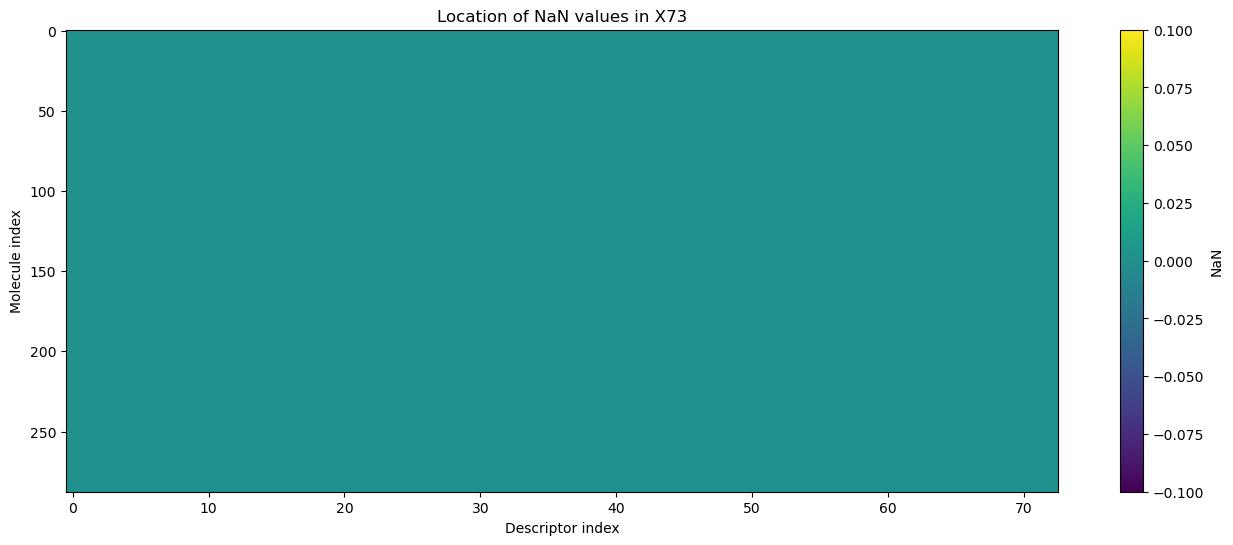

In [38]:
plt.figure(figsize=(16, 6))

plt.imshow(
    X73.isna(),
    aspect='auto',
    interpolation='none'
)

plt.xlabel('Descriptor index')
plt.ylabel('Molecule index')
plt.title('Location of NaN values in X73')

plt.colorbar(label='NaN')
plt.show()

In [39]:
y_pred_73 = cross_val_predict(
    best_xgb,
    X73,
    vY_Imax,
    cv=cv
)

In [40]:
from sklearn.metrics import mean_absolute_error, r2_score

mae_73 = mean_absolute_error(vY_Imax, y_pred_73)
r2_73 = r2_score(vY_Imax, y_pred_73)

print(f"MAE = {mae_73:.3f}")
print(f"R²  = {r2_73:.3f}")

MAE = 7.772
R²  = 0.600


In [41]:
importance_vp = pd.Series(
    best_xgb.fit(X72, vY_Imax).feature_importances_,
    index=X72.columns
).sort_values(ascending=False)

print(importance_vp.head(20))

log_vp            0.022203
ZM1Mad            0.020143
SpMax6_Bh_m_      0.018704
Mor08m            0.017858
Mor05m            0.017282
MATS1e            0.017251
SpMaxA_AEA_dm_    0.016616
VAR               0.016490
ATSC6m            0.016330
TDB06m            0.016170
ATSC8e            0.015738
SM12_AEA_bo_      0.015309
Mor11p            0.015133
HATS0p            0.015100
Mor05v            0.015093
H3u               0.014861
HGM               0.014790
RDF010s           0.014758
SM09_AEA_dm_      0.014746
H7s               0.014662
dtype: float32


In [42]:
y_pred_log_vp = cross_val_predict(
    best_xgb,
    X72[['log_vp']],
    vY_Imax,
    cv=cv
)

In [43]:
mae_log_vp = mean_absolute_error(vY_Imax, y_pred_log_vp)
r2_log_vp = r2_score(vY_Imax, y_pred_log_vp)

print(f"MAE = {mae_log_vp:.3f}")
print(f"R²  = {r2_log_vp:.3f}")

MAE = 9.986
R²  = 0.304


In [44]:
from catboost import CatBoostRegressor

In [45]:
cat_model = CatBoostRegressor(
    loss_function='MAE',
    iterations=1000,
    depth=4,
    learning_rate=0.03,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=0
)

In [72]:
y_pred_cat = cross_val_predict(
    cat_model,
    X71,
    vY_Imax,
    cv=cv,
    n_jobs=-1
)

mae_cat = mean_absolute_error(vY_Imax, y_pred_cat)
r2_cat = r2_score(vY_Imax, y_pred_cat)

print(f"CatBoost MAE = {mae_cat:.3f}")
print(f"CatBoost R²  = {r2_cat:.3f}")

CatBoost MAE = 7.590
CatBoost R²  = 0.619


In [47]:
rd_kit_df = pd.read_csv('data/waka_rdkit_expert_features.csv')
rd_kit_df

,CID,Name,rdkit_MolWt,rdkit_MolLogP,rdkit_TPSA,rdkit_NumHDonors,rdkit_NumHAcceptors,rdkit_NumRotatableBonds,rdkit_RingCount,rdkit_NumAromaticRings,...,has_aldehyde,has_alpha_beta_unsat_aldehyde,has_ketone,has_ester,has_alcohol,has_phenol,has_carboxylic_acid,has_sulfur,has_nitrogen,has_aromatic_ring
0,179,acetoin,88.106,-0.0438,37.30,1.0,2.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,240,benzaldehyde,106.124,1.4991,17.07,0.0,1.0,1.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,244,benzyl alcohol,108.140,1.1789,20.23,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,323,coumarin,146.145,1.7930,30.21,0.0,2.0,0.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,326,cumin aldehyde,148.205,2.6225,17.07,0.0,1.0,2.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,16070752,karanal,266.425,4.4041,18.46,0.0,2.0,3.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
308,16204527,isocyclocitral,304.474,4.8474,34.14,0.0,2.0,2.0,2.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
309,19871663,terpirosa,144.258,2.4395,20.23,1.0,1.0,4.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
310,44153588,tricyclodecenyl butyrate,220.312,2.9304,26.30,0.0,2.0,3.0,3.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [48]:
rd_kit_df = rd_kit_df.loc[valid_mask, :]
rd_kit_df

,CID,Name,rdkit_MolWt,rdkit_MolLogP,rdkit_TPSA,rdkit_NumHDonors,rdkit_NumHAcceptors,rdkit_NumRotatableBonds,rdkit_RingCount,rdkit_NumAromaticRings,...,has_aldehyde,has_alpha_beta_unsat_aldehyde,has_ketone,has_ester,has_alcohol,has_phenol,has_carboxylic_acid,has_sulfur,has_nitrogen,has_aromatic_ring
0,179,acetoin,88.106,-0.0438,37.30,1.0,2.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,240,benzaldehyde,106.124,1.4991,17.07,0.0,1.0,1.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,244,benzyl alcohol,108.140,1.1789,20.23,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,323,coumarin,146.145,1.7930,30.21,0.0,2.0,0.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,326,cumin aldehyde,148.205,2.6225,17.07,0.0,1.0,2.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,15461361,cis-3-hexenyl tiglate,182.263,2.8521,26.30,0.0,2.0,5.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
306,16063567,helvetolide,284.440,4.3397,35.53,0.0,3.0,6.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
307,16070752,karanal,266.425,4.4041,18.46,0.0,2.0,3.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
310,44153588,tricyclodecenyl butyrate,220.312,2.9304,26.30,0.0,2.0,3.0,3.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [49]:

merged_waka_rd_kit = pd.merge(
    waka_dragon_df[['CID', 'Name']],
    rd_kit_df.drop(columns='Name'),
    on='CID',
    how='left'
)
merged_waka_rd_kit

,CID,Name,rdkit_MolWt,rdkit_MolLogP,rdkit_TPSA,rdkit_NumHDonors,rdkit_NumHAcceptors,rdkit_NumRotatableBonds,rdkit_RingCount,rdkit_NumAromaticRings,...,has_aldehyde,has_alpha_beta_unsat_aldehyde,has_ketone,has_ester,has_alcohol,has_phenol,has_carboxylic_acid,has_sulfur,has_nitrogen,has_aromatic_ring
0,179,acetoin,88.106,-0.0438,37.30,1.0,2.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,240,benzaldehyde,106.124,1.4991,17.07,0.0,1.0,1.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,244,benzyl alcohol,108.140,1.1789,20.23,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,323,coumarin,146.145,1.7930,30.21,0.0,2.0,0.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,326,cumin aldehyde,148.205,2.6225,17.07,0.0,1.0,2.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,15461361,cis-3-hexenyl tiglate,182.263,2.8521,26.30,0.0,2.0,5.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
284,16063567,helvetolide,284.440,4.3397,35.53,0.0,3.0,6.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
285,16070752,karanal,266.425,4.4041,18.46,0.0,2.0,3.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
286,44153588,tricyclodecenyl butyrate,220.312,2.9304,26.30,0.0,2.0,3.0,3.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [50]:
X_rdkit = pd.concat(
    [
        X73.reset_index(drop=True),
        merged_waka_rd_kit.drop(columns=['CID', 'Name']).reset_index(drop=True)
    ],
    axis=1
)

print(X73.shape)
print(X_rdkit.shape)

(288, 73)
(288, 93)


In [51]:
duplicate_cols = X_rdkit.columns[
    X_rdkit.columns.duplicated()
]

print(duplicate_cols)

Index([], dtype='str')


In [73]:
y_pred_rdkit = cross_val_predict(
    best_xgb,
    X_rdkit,
    vY_Imax,
    cv=cv,
    n_jobs=-1
)

mae_rdkit = mean_absolute_error(
    vY_Imax,
    y_pred_rdkit
)

r2_rdkit = r2_score(
    vY_Imax,
    y_pred_rdkit
)

print(f"MAE = {mae_rdkit:.3f}")
print(f"R² = {r2_rdkit:.3f}")

MAE = 7.640
R² = 0.609


In [53]:
best_xgb.fit(X_rdkit, vY_Imax)

importance_rdkit = pd.Series(
    best_xgb.feature_importances_,
    index=X_rdkit.columns
).sort_values(ascending=False)

importance_rdkit.head(30)

rdkit_NumHDonors       0.023901
log_vp                 0.019812
SpMax6_Bh_m_           0.017349
rdkit_MolWt            0.016634
ZM1Mad                 0.016155
rdkit_FractionCSP3     0.014945
ATSC8e                 0.014504
ATS5m                  0.014423
SpMaxA_AEA_dm_         0.014326
AVS_B_s_               0.014010
ATSC6m                 0.013778
MATS1e                 0.013776
rdkit_NumHAcceptors    0.013641
VAR                    0.013632
Mor11p                 0.013540
Mor05m                 0.013472
Mor08m                 0.013466
RDF025u                0.013370
Mor11v                 0.013163
TDB06m                 0.013130
R6v                    0.013126
has_aldehyde           0.013067
HGM                    0.013058
ATSC1e                 0.012962
H7s                    0.012678
VE2_B_m_               0.012672
rdkit_TPSA             0.012549
H3u                    0.012468
RDF025s                0.012424
Mor05v                 0.012399
dtype: float32

In [54]:
rdkit_cols = [
    col for col in X_rdkit.columns
    if col.startswith('rdkit_')
    or col.startswith('has_')
]

importance_rdkit[
    importance_rdkit.index.isin(rdkit_cols)
].head(20)

rdkit_NumHDonors                 0.023901
rdkit_MolWt                      0.016634
rdkit_FractionCSP3               0.014945
rdkit_NumHAcceptors              0.013641
has_aldehyde                     0.013067
rdkit_TPSA                       0.012549
rdkit_MolLogP                    0.011707
rdkit_NumRotatableBonds          0.011171
has_ketone                       0.010088
has_phenol                       0.008428
has_nitrogen                     0.005129
rdkit_NumAromaticRings           0.000000
has_alpha_beta_unsat_aldehyde    0.000000
rdkit_HeavyAtomCount             0.000000
rdkit_RingCount                  0.000000
has_ester                        0.000000
has_alcohol                      0.000000
has_carboxylic_acid              0.000000
has_sulfur                       0.000000
has_aromatic_ring                0.000000
dtype: float32

In [55]:
xgb_rdkit_reg = XGBRegressor(
    objective='reg:absoluteerror',
    random_state=42,
    n_jobs=-1
)

In [333]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, KFold

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb_rdkit_reg = XGBRegressor(
    objective='reg:absoluteerror',
    random_state=42,
    n_jobs=-1
)

param_grid_rdkit = {
    'max_depth': [2, 3, 4],
    'learning_rate': [0.02, 0.03, 0.05],
    'n_estimators': [600, 800, 1000],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [1, 3, 10]
}

grid_rdkit = GridSearchCV(
    estimator=xgb_rdkit_reg,
    param_grid=param_grid_rdkit,
    scoring='neg_mean_absolute_error',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_rdkit.fit(X_rdkit, vY_Imax)

print("Best CV MAE:", -grid_rdkit.best_score_)
print("Best params:")
print(grid_rdkit.best_params_)

Fitting 5 folds for each of 2430 candidates, totalling 12150 fits
Best CV MAE: 7.363671596937879
Best params:
{'colsample_bytree': 0.9, 'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 600, 'reg_alpha': 0.1, 'reg_lambda': 3, 'subsample': 0.8}


In [57]:
best_xgb_rdkit = XGBRegressor(
    objective='reg:absoluteerror',
    colsample_bytree=0.9,
    learning_rate=0.02,
    max_depth=4,
    n_estimators=600,
    reg_alpha = 0.1,
    reg_lambda = 3,
    subsample=0.8,
    random_state=42,
    n_jobs=-1
)

In [74]:
y_pred_rdkit_best = cross_val_predict(
    best_xgb_rdkit,
    X_rdkit,
    vY_Imax,
    cv=cv,
    n_jobs=-1
)

mae_rdkit_best = mean_absolute_error(vY_Imax, y_pred_rdkit_best)
r2_rdkit_best = r2_score(vY_Imax, y_pred_rdkit_best)

print(f"MAE = {mae_rdkit_best:.3f}")
print(f"R²  = {r2_rdkit_best:.3f}")

MAE = 7.365
R²  = 0.630


In [63]:
Imax_pred_dict = {
    'CID': waka_dragon_df['CID'].values.astype(int),
    'Imax_pred': y_pred_rdkit_best,
    'Imax_true': vY_Imax
}
Imax_pred_df = pd.DataFrame(Imax_pred_dict)
Imax_pred_df


,CID,Imax_pred,Imax_true
0,179,48.872299,49.69
1,240,59.886871,62.02
2,244,46.243999,30.28
3,323,35.450882,26.79
4,326,44.540329,49.53
...,...,...,...
305,15461361,46.164852,44.85
306,16063567,19.859747,7.05
307,16070752,18.996866,48.88
310,44153588,31.476618,24.15


In [64]:
Imax_pred_df.to_csv('data/Imax_pred.csv', index=False)

In [75]:
from sklearn.dummy import DummyRegressor

dummy_reg = DummyRegressor(strategy='mean')
y_pred_dummy = cross_val_predict(
    dummy_reg,
    X_rdkit,
    vY_Imax,
    cv=cv
)
mae_rdkit_dummy = mean_absolute_error(vY_Imax, y_pred_dummy)
r2_rdkit_dummy = r2_score(vY_Imax, y_pred_dummy)

print(f"MAE = {mae_rdkit_dummy:.3f}")
print(f"R²  = {r2_rdkit_dummy:.3f}")

MAE = 12.137
R²  = -0.008


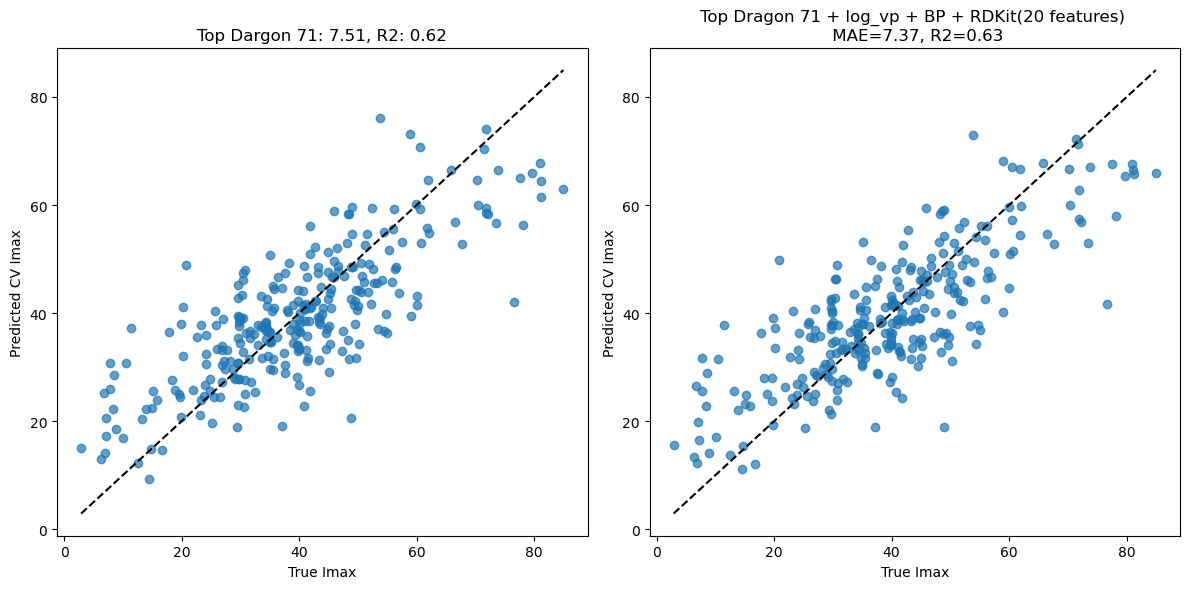

In [345]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 6)
)

# Model 1
ax[0].scatter(
    vY_Imax,
    y_pred_71,
    alpha=0.7
)

ax[0].plot(
    [vY_Imax.min(), vY_Imax.max()],
    [vY_Imax.min(), vY_Imax.max()],
    '--k'
)

ax[0].set_title(
    f'Top Dargon 71: {mae_71:.2f}, R2: {r2_71:.2f}'
)

ax[0].set_xlabel('True Imax')
ax[0].set_ylabel('Predicted CV Imax')

# Model 2
ax[1].scatter(
    vY_Imax,
    y_pred_rdkit_best,
    alpha=0.7
)

ax[1].plot(
    [vY_Imax.min(), vY_Imax.max()],
    [vY_Imax.min(), vY_Imax.max()],
    '--k'
)

ax[1].set_title(
    f'Top Dragon 71 + log_vp + BP + RDKit(20 features) \n MAE={mae_rdkit_best:.2f}, R2={r2_rdkit_best:.2f}'
)

ax[1].set_xlabel('True Imax')
ax[1].set_ylabel('Predicted CV Imax')

plt.tight_layout()
plt.show()

In [342]:
feature_sets = {
    'X71_dragon': X71,
    'X72_dragon_log_vp': X72,
    'X73_dragon_log_vp_bp': X73,
    'X_rdkit_all': X_rdkit,
}

for name, X in feature_sets.items():
    y_pred = cross_val_predict(
        best_xgb_rdkit,
        X,
        vY_Imax,
        cv=cv,
        n_jobs=-1
    )

    mae = mean_absolute_error(vY_Imax, y_pred)
    r2 = r2_score(vY_Imax, y_pred)

    print(f'{name:25s}  MAE={mae:.3f}  R²={r2:.3f}')

X71_dragon                 MAE=7.500  R²=0.619
X72_dragon_log_vp          MAE=7.527  R²=0.616
X73_dragon_log_vp_bp       MAE=7.512  R²=0.618
X_rdkit_all                MAE=7.365  R²=0.630


In [349]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, StackingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import RidgeCV

In [350]:
# Feature matrix
X_stack = X_rdkit.copy()   # or X_rdkit, depending on your variable name
y = vY_Imax.copy()

In [353]:
xgb_model = XGBRegressor(
    objective='reg:absoluteerror',
    colsample_bytree=0.7,
    learning_rate=0.03,
    max_depth=2,
    n_estimators=800,
    subsample=0.7,
    random_state=42,
    n_jobs=-1
)

extra_model = ExtraTreesRegressor(
    n_estimators=500,
    max_features='sqrt',
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model = RandomForestRegressor(
    n_estimators=500,
    max_features='sqrt',
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

svr_model = make_pipeline(
    StandardScaler(),
    SVR(kernel='rbf', C=10, epsilon=2.0, gamma='scale')
)

gpr_model = make_pipeline(
    StandardScaler(),
    GaussianProcessRegressor(
        kernel=ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0),
        alpha=1e-6,
        normalize_y=True,
        random_state=42
    )
)

In [354]:
stack_model = StackingRegressor(
    estimators=[
        ('xgb', xgb_model),
        ('extra', extra_model),
        ('rf', rf_model),
        ('svr', svr_model),
        ('gpr', gpr_model),
    ],
    final_estimator=RidgeCV(alphas=np.logspace(-3, 3, 13)),
    cv=cv,
    n_jobs=-1,
    passthrough=False
)

In [355]:
y_pred_stack = cross_val_predict(
    stack_model,
    X_stack,
    y,
    cv=cv,
    n_jobs=-1
)

print("Stacking model")
print(f"MAE = {mean_absolute_error(y, y_pred_stack):.3f}")
print(f"R²  = {r2_score(y, y_pred_stack):.3f}")
print(f"Correlation = {np.corrcoef(y, y_pred_stack)[0, 1]:.3f}")

Stacking model
MAE = 7.713
R²  = 0.608
Correlation = 0.781


In [356]:
stack_model_no_gpr = StackingRegressor(
    estimators=[
        ('xgb', xgb_model),
        ('extra', extra_model),
        ('rf', rf_model),
        ('svr', svr_model),
    ],
    final_estimator=RidgeCV(alphas=np.logspace(-3, 3, 13)),
    cv=cv,
    n_jobs=-1,
    passthrough=False
)

y_pred_stack_no_gpr = cross_val_predict(
    stack_model_no_gpr,
    X_stack,
    y,
    cv=cv,
    n_jobs=-1
)

print("Stacking model without GPR")
print(f"MAE = {mean_absolute_error(y, y_pred_stack_no_gpr):.3f}")
print(f"R²  = {r2_score(y, y_pred_stack_no_gpr):.3f}")

Stacking model without GPR
MAE = 7.701
R²  = 0.610


In [357]:
models = {
    "XGBoost": xgb_model,
    "ExtraTrees": extra_model,
    "RandomForest": rf_model,
    "SVR": svr_model,
    "GPR": gpr_model,
}

for name, model in models.items():
    pred = cross_val_predict(
        model,
        X_stack,
        y,
        cv=cv,
        n_jobs=-1
    )

    print(
        f"{name:15s} "
        f"MAE={mean_absolute_error(y,pred):.3f} "
        f"R²={r2_score(y,pred):.3f}"
    )

XGBoost         MAE=7.644 R²=0.612
ExtraTrees      MAE=7.742 R²=0.607
RandomForest    MAE=7.755 R²=0.603
SVR             MAE=8.040 R²=0.588
GPR             MAE=7.937 R²=0.591


In [378]:
waka_dragon_df['CID']

0           179
1           240
2           244
3           323
4           326
         ...   
305    15461361
306    16063567
307    16070752
310    44153588
311    57353762
Name: CID, Length: 288, dtype: int64

In [379]:
residual_df = pd.DataFrame({
    'CID': waka_dragon_df['CID'],
    'Name': waka_dragon_df['Name'],
    'Imax_true': vY_Imax,
    'Imax_pred': y_pred_rdkit_best
})

residual_df['residual'] = residual_df['Imax_true'] - residual_df['Imax_pred']
residual_df['abs_error'] = residual_df['residual'].abs()

flags = [
    'has_aldehyde',
    'has_alpha_beta_unsat_aldehyde',
    'has_ketone',
    'has_ester',
    'has_alcohol',
    'has_phenol',
    'has_carboxylic_acid',
    'has_sulfur',
    'has_nitrogen',
    'has_aromatic_ring'
]

residual_df = pd.concat(
    [
        residual_df.reset_index(drop=True),
        rd_kit_df[flags].reset_index(drop=True)
    ],
    axis=1
)

In [380]:
residual_df

,CID,Name,Imax_true,Imax_pred,residual,abs_error,has_aldehyde,has_alpha_beta_unsat_aldehyde,has_ketone,has_ester,has_alcohol,has_phenol,has_carboxylic_acid,has_sulfur,has_nitrogen,has_aromatic_ring
0,179,acetoin,49.69,48.872299,0.817701,0.817701,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,240,benzaldehyde,62.02,59.886871,2.133129,2.133129,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,244,benzyl alcohol,30.28,46.243999,-15.963999,15.963999,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,323,coumarin,26.79,35.450882,-8.660882,8.660882,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,326,cumin aldehyde,49.53,44.540329,4.989671,4.989671,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,15461361,cis-3-hexenyl tiglate,44.85,46.164852,-1.314852,1.314852,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
284,16063567,helvetolide,7.05,19.859747,-12.809747,12.809747,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
285,16070752,karanal,48.88,18.996866,29.883134,29.883134,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
286,44153588,tricyclodecenyl butyrate,24.15,31.476618,-7.326618,7.326618,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [381]:
summary = []

for flag in flags:

    idx = residual_df[flag] == 1

    if idx.sum() < 5:
        continue

    summary.append({
        "group": flag,
        "N": idx.sum(),
        "Mean residual": residual_df.loc[idx, "residual"].mean(),
        "MAE": residual_df.loc[idx, "abs_error"].mean(),
        "Std residual": residual_df.loc[idx, "residual"].std()
    })

summary_df = (
    pd.DataFrame(summary)
    .sort_values("MAE", ascending=False)
)

summary_df

,group,N,Mean residual,MAE,Std residual
1,has_alpha_beta_unsat_aldehyde,8,-1.179767,8.656162,12.764488
5,has_phenol,16,0.948861,8.475275,10.176550
0,has_aldehyde,41,3.873974,8.338641,10.731925
4,has_alcohol,68,-1.733319,7.866373,10.054992
2,has_ketone,42,0.413324,7.094060,9.082483
6,has_aromatic_ring,89,-0.450459,6.984091,8.801906
3,has_ester,120,-0.219235,6.909588,8.819627


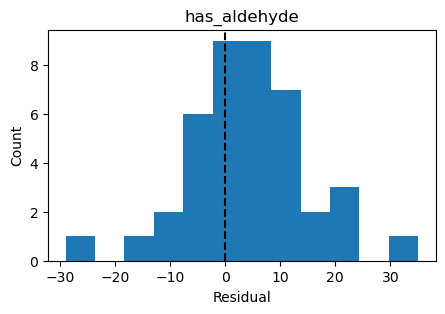

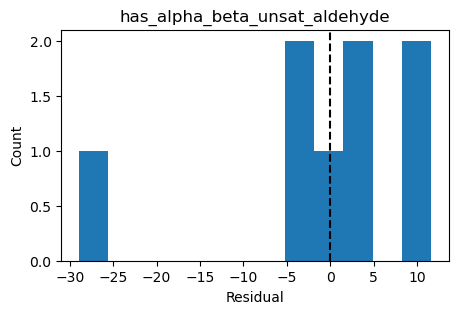

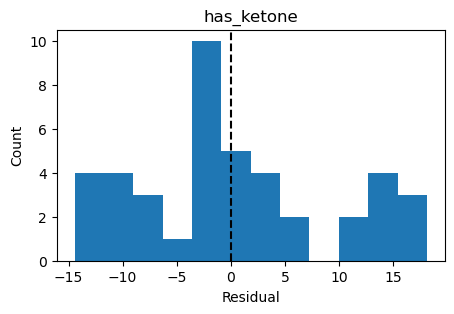

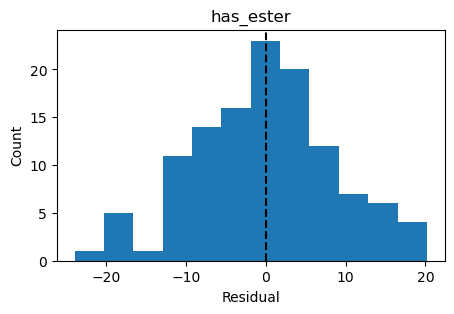

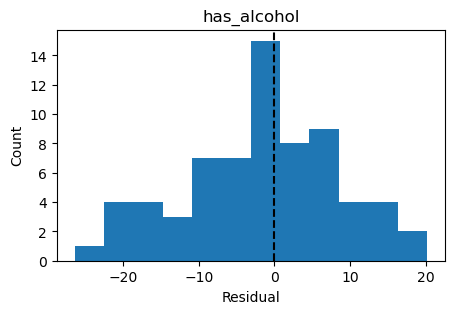

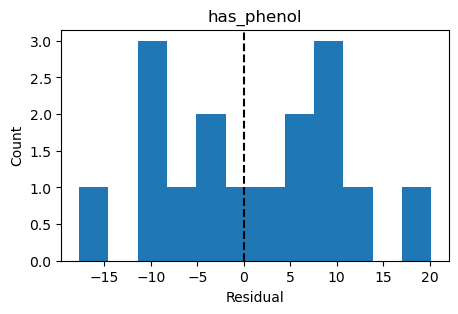

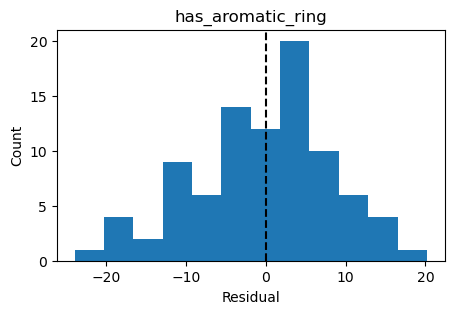

In [371]:
import matplotlib.pyplot as plt

for flag in flags:

    idx = residual_df[flag] == 1

    if idx.sum() < 5:
        continue

    plt.figure(figsize=(5,3))

    plt.hist(
        residual_df.loc[idx,'residual'],
        bins=12
    )

    plt.axvline(0,color='k',ls='--')

    plt.title(flag)
    plt.xlabel("Residual")
    plt.ylabel("Count")

    plt.show()

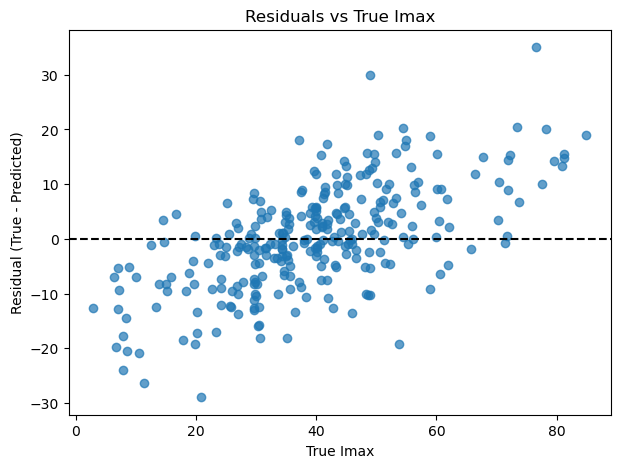

In [386]:
plt.figure(figsize=(7,5))

plt.scatter(
    residual_df['Imax_true'],
    residual_df['residual'],
    alpha=0.7
)

plt.axhline(0, color='k', ls='--')

plt.xlabel("True Imax")
plt.ylabel("Residual (True - Predicted)")
plt.title("Residuals vs True Imax")

plt.show()

In [373]:
residual_df['Imax_bin'] = pd.qcut(
    residual_df['Imax_true'],
    q=5,
    duplicates='drop'
)

bin_summary = (
    residual_df
    .groupby('Imax_bin')
    .agg(
        N=('Imax_true','size'),
        MAE=('abs_error','mean'),
        MeanResidual=('residual','mean'),
        StdResidual=('residual','std')
    )
)

print(bin_summary)

                   N       MAE  MeanResidual  StdResidual
Imax_bin                                                 
(2.899, 27.596]   58  9.250285     -8.532542     7.961496
(27.596, 35.056]  57  5.233197     -3.118994     6.124788
(35.056, 41.91]   58  5.788646      1.075165     7.337033
(41.91, 50.56]    57  7.059758      3.822904     8.396236
(50.56, 84.97]    58  9.453253      7.558690     9.044285


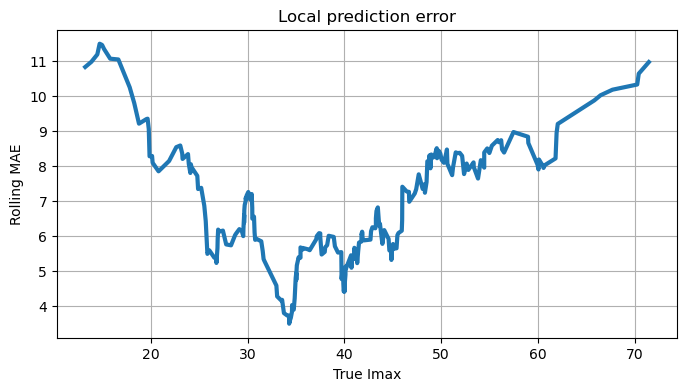

In [374]:
plot_df = residual_df.sort_values('Imax_true').reset_index(drop=True)

plot_df['rolling_mae'] = (
    plot_df['abs_error']
    .rolling(window=30, center=True)
    .mean()
)

plt.figure(figsize=(8,4))

plt.plot(
    plot_df['Imax_true'],
    plot_df['rolling_mae'],
    linewidth=3
)

plt.xlabel("True Imax")
plt.ylabel("Rolling MAE")
plt.title("Local prediction error")

plt.grid(True)

plt.show()

In [390]:
corr = residual_df['Imax_true'].corr(residual_df['residual'])
print(f"Correlation(Imax, abs error) = {corr:.3f}")

Correlation(Imax, abs error) = 0.632


In [391]:
from scipy.stats import linregress

x = residual_df["Imax_pred"]
y = residual_df["residual"]

slope, intercept, r, p, stderr = linregress(x, y)

print(f"Slope = {slope:.3f}")
print(f"Intercept = {intercept:.3f}")
print(f"R = {r:.3f}")
print(f"R² = {r**2:.3f}")
print(f"p-value = {p:.3e}")

Slope = 0.024
Intercept = -0.801
R = 0.031
R² = 0.001
p-value = 5.989e-01


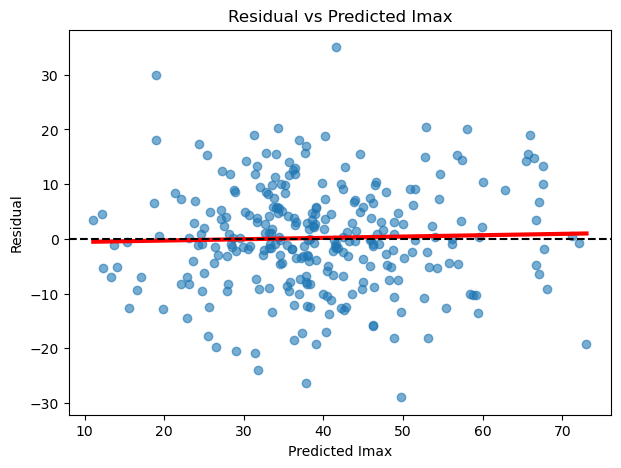

In [388]:
plt.figure(figsize=(7,5))

plt.scatter(x, y, alpha=0.6)

xx = np.linspace(x.min(), x.max(), 100)
plt.plot(xx, intercept + slope*xx, 'r', lw=3)

plt.axhline(0, color='k', ls='--')

plt.xlabel("Predicted Imax")
plt.ylabel("Residual")
plt.title("Residual vs Predicted Imax")
plt.show()

In [437]:
import umap.umap_ as umap

reducer = umap.UMAP(
    n_neighbors=20,
    min_dist=0.3,
    metric='euclidean',
    random_state=42
)

embedding = reducer.fit_transform(X_rdkit)

c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


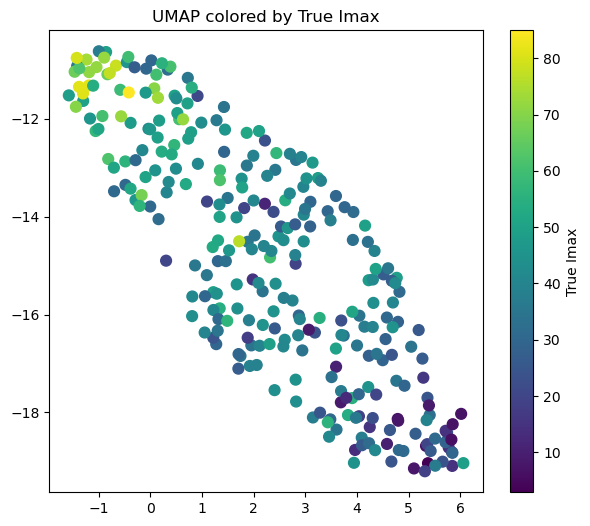

In [438]:
plt.figure(figsize=(7,6))

sc = plt.scatter(
    embedding[:,0],
    embedding[:,1],
    c=vY_Imax,
    cmap='viridis',
    s=60
)

plt.colorbar(sc,label="True Imax")

plt.title("UMAP colored by True Imax")
plt.show()

In [445]:
X_rdkit_umap = X_rdkit.copy()

X_rdkit_umap['UMAP1'] = embedding[:, 0]
X_rdkit_umap['UMAP2'] = embedding[:, 1]

In [446]:
y_pred_umap = cross_val_predict(
    best_xgb_rdkit,
    X_rdkit_umap,
    vY_Imax,
    cv=cv,
    n_jobs=-1
)

print(f"MAE = {mean_absolute_error(vY_Imax, y_pred_umap):.3f}")
print(f"R²  = {r2_score(vY_Imax, y_pred_umap):.3f}")

MAE = 7.706
R²  = 0.607


In [447]:
X_umap_only = pd.DataFrame({
    'UMAP1': embedding[:, 0],
    'UMAP2': embedding[:, 1]
})

In [448]:
y_pred_umap_only = cross_val_predict(
    best_xgb_rdkit,
    X_umap_only,
    vY_Imax,
    cv=cv,
    n_jobs=-1
)

print(f"MAE = {mean_absolute_error(vY_Imax, y_pred_umap_only):.3f}")
print(f"R²  = {r2_score(vY_Imax, y_pred_umap_only):.3f}")

MAE = 10.317
R²  = 0.287


In [444]:
X_rdkit.shape

(288, 93)

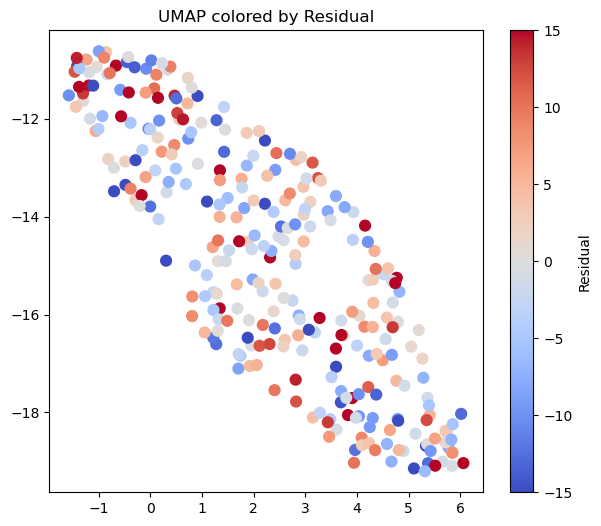

In [439]:
plt.figure(figsize=(7,6))

sc = plt.scatter(
    embedding[:,0],
    embedding[:,1],
    c=residual_df["residual"],
    cmap='coolwarm',
    s=60,
    vmin=-15,
    vmax=15
)

plt.colorbar(sc,label="Residual")

plt.title("UMAP colored by Residual")
plt.show()

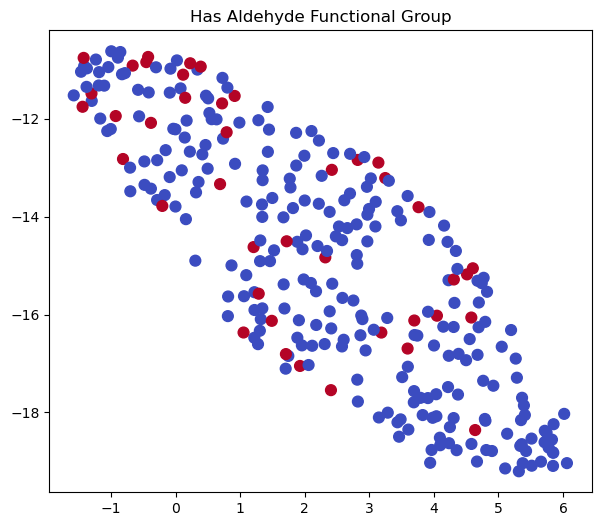

In [449]:
plt.figure(figsize=(7,6))

plt.scatter(
    embedding[:,0],
    embedding[:,1],
    c=rd_kit_df["has_aldehyde"],
    cmap="coolwarm",
    s=60
)

plt.title("Has Aldehyde Functional Group")
plt.show()

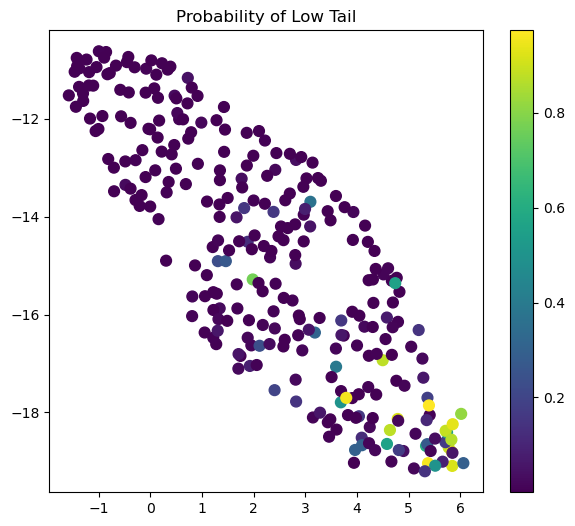

In [441]:
plt.figure(figsize=(7,6))

sc = plt.scatter(
    embedding[:,0],
    embedding[:,1],
    c=low_prob,
    cmap="viridis",
    s=60
)

plt.colorbar(sc)

plt.title("Probability of Low Tail")
plt.show()

In [442]:
umap_df = pd.DataFrame({
    "UMAP1": embedding[:, 0],
    "UMAP2": embedding[:, 1],
    "Imax": vY_Imax,
    "Prediction": y_pred_rdkit_best,
    "Residual": residual_df["residual"],
    "LowProb": low_prob,
    "HighProb": high_prob,
})

# Add RDKit functional group flags
umap_df = pd.concat(
    [umap_df, rd_kit_df[flags].reset_index(drop=True)],
    axis=1
)

ValueError: array length 288 does not match index length 306

In [424]:
from sklearn.base import clone

In [431]:
X = X_rdkit.copy()
y = np.asarray(vY_Imax)

low_thr = 20
high_thr = 60

y_pred_blend = np.zeros(len(y))
y_pred_global_cv = np.zeros(len(y))

low_prob_cv = np.zeros(len(y))
high_prob_cv = np.zeros(len(y))

In [432]:
rf_tail_base = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_tail_grid = {
    "n_estimators": [200, 500],
    "max_depth": [2, 3, 4],
    "min_samples_leaf": [2, 3, 5],
    "max_features": ["sqrt", 0.5, 1.0],
}

In [433]:
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):

    print(f"Fold {fold}")

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    y_train = y[train_idx]
    y_test = y[test_idx]

    # -----------------------------
    # 1. Global regressor
    # -----------------------------
    global_model = clone(best_xgb_rdkit)
    global_model.fit(X_train, y_train)

    pred_global_test = global_model.predict(X_test)
    y_pred_global_cv[test_idx] = pred_global_test

    # -----------------------------
    # 2. Tail classifiers
    # -----------------------------
    low_train_class = (y_train <= low_thr).astype(int)
    high_train_class = (y_train >= high_thr).astype(int)

    low_clf = clone(low_clf_base)
    high_clf = clone(high_clf_base)

    low_clf.fit(X_train, low_train_class)
    high_clf.fit(X_train, high_train_class)

    p_low = low_clf.predict_proba(X_test)[:, 1]
    p_high = high_clf.predict_proba(X_test)[:, 1]

    low_prob_cv[test_idx] = p_low
    high_prob_cv[test_idx] = p_high

    # -----------------------------
    # 3. Tail specialist regressors
    # -----------------------------
    low_mask_train = y_train <= low_thr
    high_mask_train = y_train >= high_thr

    pred_low_test = pred_global_test.copy()
    pred_high_test = pred_global_test.copy()

    if low_mask_train.sum() >= 10:

        low_grid = GridSearchCV(
            estimator=clone(rf_tail_base),
            param_grid=rf_tail_grid,
            scoring="neg_mean_absolute_error",
            cv=3,
            n_jobs=-1
        )

        low_grid.fit(
            X_train.loc[low_mask_train],
            y_train[low_mask_train]
        )

        pred_low_test = low_grid.best_estimator_.predict(X_test)

        print("  Low tail N:", low_mask_train.sum(),
              "Best params:", low_grid.best_params_)

    if high_mask_train.sum() >= 10:

        high_grid = GridSearchCV(
            estimator=clone(rf_tail_base),
            param_grid=rf_tail_grid,
            scoring="neg_mean_absolute_error",
            cv=3,
            n_jobs=-1
        )

        high_grid.fit(
            X_train.loc[high_mask_train],
            y_train[high_mask_train]
        )

        pred_high_test = high_grid.best_estimator_.predict(X_test)

        print("  High tail N:", high_mask_train.sum(),
              "Best params:", high_grid.best_params_)

    # -----------------------------
    # 4. Probability blending
    # -----------------------------
    p_sum = p_low + p_high

    # avoid overweighting if both probabilities are nonzero
    p_mid = np.clip(1 - p_sum, 0, 1)

    # normalized weights
    total = p_mid + p_low + p_high

    w_mid = p_mid / total
    w_low = p_low / total
    w_high = p_high / total

    pred_blend_test = (
        w_mid * pred_global_test +
        w_low * pred_low_test +
        w_high * pred_high_test
    )

    y_pred_blend[test_idx] = pred_blend_test

Fold 1
  Low tail N: 26 Best params: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 500}
  High tail N: 22 Best params: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 200}
Fold 2
  Low tail N: 23 Best params: {'max_depth': 2, 'max_features': 1.0, 'min_samples_leaf': 5, 'n_estimators': 200}
  High tail N: 20 Best params: {'max_depth': 4, 'max_features': 0.5, 'min_samples_leaf': 5, 'n_estimators': 200}
Fold 3
  Low tail N: 21 Best params: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 500}
  High tail N: 21 Best params: {'max_depth': 3, 'max_features': 1.0, 'min_samples_leaf': 2, 'n_estimators': 500}
Fold 4
  Low tail N: 25 Best params: {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 200}
  High tail N: 24 Best params: {'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 200}
Fold 5
  Low tail N: 25 Best params: {'max_depth': 4, 'ma

In [434]:
print("Global model:")
print(f"MAE = {mean_absolute_error(y, y_pred_global_cv):.3f}")
print(f"R²  = {r2_score(y, y_pred_global_cv):.3f}")

print("\nTail-specialist blended model:")
print(f"MAE = {mean_absolute_error(y, y_pred_blend):.3f}")
print(f"R²  = {r2_score(y, y_pred_blend):.3f}")
print(f"Correlation = {np.corrcoef(y, y_pred_blend)[0, 1]:.3f}")

Global model:
MAE = 7.569
R²  = 0.612

Tail-specialist blended model:
MAE = 7.571
R²  = 0.607
Correlation = 0.787


In [435]:
print("Mean p_low:", low_prob_cv.mean())
print("Mean p_high:", high_prob_cv.mean())

print("p_low > 0.5:", (low_prob_cv > 0.5).sum())
print("p_high > 0.5:", (high_prob_cv > 0.5).sum())

Mean p_low: 0.07792792372391785
Mean p_high: 0.0842384089958917
p_low > 0.5: 18
p_high > 0.5: 20


In [436]:
alpha = 0.5
p_low_adj = alpha * p_low
p_high_adj = alpha * p_high

In [425]:
low_clf_base = XGBClassifier(
    max_depth=3,
    learning_rate=0.05,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

high_clf_base = clone(low_clf_base)

rf_corr_base = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [2, 3, 4],
    "min_samples_leaf": [2, 3, 5],
    "max_features": ["sqrt", 0.5, 1.0],
}

In [426]:
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):

    print(f"Fold {fold}")

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    y_train = y[train_idx]
    y_test = y[test_idx]

    # -----------------------------
    # 1. Global regression model
    # -----------------------------
    global_model = clone(best_xgb_rdkit)
    global_model.fit(X_train, y_train)

    pred_train = global_model.predict(X_train)
    pred_test = global_model.predict(X_test)

    y_pred_global_cv[test_idx] = pred_test

    residual_train = y_train - pred_train

    # -----------------------------
    # 2. Tail classifiers
    # -----------------------------
    low_train_class = (y_train <= low_thr).astype(int)
    high_train_class = (y_train >= high_thr).astype(int)

    low_clf = clone(low_clf_base)
    high_clf = clone(high_clf_base)

    low_clf.fit(X_train, low_train_class)
    high_clf.fit(X_train, high_train_class)

    p_low_test = low_clf.predict_proba(X_test)[:, 1]
    p_high_test = high_clf.predict_proba(X_test)[:, 1]

    low_prob_cv[test_idx] = p_low_test
    high_prob_cv[test_idx] = p_high_test

    # -----------------------------
    # 3. Correction feature matrices
    # -----------------------------
    X_corr_train = X_train.copy()
    X_corr_test = X_test.copy()

    X_corr_train["pred_imax"] = pred_train
    X_corr_test["pred_imax"] = pred_test

    # -----------------------------
    # 4. Train low-tail residual expert
    # -----------------------------
    corrected_test = pred_test.copy()

    low_train_mask = y_train <= low_thr
    high_train_mask = y_train >= high_thr

    low_test_activate = p_low_test > 0.80
    high_test_activate = p_high_test > 0.80

    if low_train_mask.sum() >= 10 and low_test_activate.sum() > 0:

        low_grid = GridSearchCV(
            estimator=clone(rf_corr_base),
            param_grid=rf_param_grid,
            scoring="neg_mean_absolute_error",
            cv=3,
            n_jobs=-1
        )

        low_grid.fit(
            X_corr_train.loc[low_train_mask],
            residual_train[low_train_mask]
        )

        delta_low = low_grid.best_estimator_.predict(
            X_corr_test.loc[low_test_activate]
        )

        corrected_test[low_test_activate] += delta_low

        print("  Low correction:", low_test_activate.sum(),
              "Best params:", low_grid.best_params_)

    # -----------------------------
    # 5. Train high-tail residual expert
    # -----------------------------
    if high_train_mask.sum() >= 10 and high_test_activate.sum() > 0:

        high_grid = GridSearchCV(
            estimator=clone(rf_corr_base),
            param_grid=rf_param_grid,
            scoring="neg_mean_absolute_error",
            cv=3,
            n_jobs=-1
        )

        high_grid.fit(
            X_corr_train.loc[high_train_mask],
            residual_train[high_train_mask]
        )

        delta_high = high_grid.best_estimator_.predict(
            X_corr_test.loc[high_test_activate]
        )

        corrected_test[high_test_activate] += delta_high

        print("  High correction:", high_test_activate.sum(),
              "Best params:", high_grid.best_params_)

    y_pred_corrected[test_idx] = corrected_test

Fold 1
  High correction: 1 Best params: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 200}
Fold 2
  Low correction: 5 Best params: {'max_depth': 2, 'max_features': 1.0, 'min_samples_leaf': 3, 'n_estimators': 200}
  High correction: 7 Best params: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 500}
Fold 3
  Low correction: 3 Best params: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 200}
  High correction: 1 Best params: {'max_depth': 2, 'max_features': 0.5, 'min_samples_leaf': 5, 'n_estimators': 200}
Fold 4
  Low correction: 3 Best params: {'max_depth': 2, 'max_features': 0.5, 'min_samples_leaf': 5, 'n_estimators': 500}
  High correction: 1 Best params: {'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 500}
Fold 5
  Low correction: 3 Best params: {'max_depth': 4, 'max_features': 1.0, 'min_samples_leaf': 2, 'n_estimators': 500}
  High correction: 2 Best par

In [427]:
print("Global model:")
print(f"MAE = {mean_absolute_error(y, y_pred_global_cv):.3f}")
print(f"R²  = {r2_score(y, y_pred_global_cv):.3f}")

print("\nTail-corrected model:")
print(f"MAE = {mean_absolute_error(y, y_pred_corrected):.3f}")
print(f"R²  = {r2_score(y, y_pred_corrected):.3f}")
print(f"Correlation = {np.corrcoef(y, y_pred_corrected)[0, 1]:.3f}")

Global model:
MAE = 7.569
R²  = 0.612

Tail-corrected model:
MAE = 7.533
R²  = 0.615
Correlation = 0.784


In [428]:
print("Low corrections applied:", (low_prob_cv > 0.80).sum())
print("High corrections applied:", (high_prob_cv > 0.80).sum())

Low corrections applied: 14
High corrections applied: 12


In [429]:
for t in [0.50, 0.60, 0.70, 0.80, 0.90]:
    print(t, 
          "low activated:", (low_prob_cv > t).sum(),
          "high activated:", (high_prob_cv > t).sum())

0.5 low activated: 18 high activated: 20
0.6 low activated: 15 high activated: 19
0.7 low activated: 15 high activated: 15
0.8 low activated: 14 high activated: 12
0.9 low activated: 6 high activated: 10


https://github.com/soda-inria/tabicl

In [84]:
bins = [0, 20, 60, 100]
y_class = pd.cut(
    vY_Imax,
    bins=bins,
    labels=[0, 1, 2],
    include_lowest=True
).astype(int)

In [85]:
from xgboost import XGBClassifier

clf = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=600,
    max_depth=4,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=3,
    random_state=42,
    n_jobs=-1,
)

In [86]:
from sklearn.model_selection import cross_val_predict

y_pred_class = cross_val_predict(
    clf,
    X_rdkit,
    y_class,
    cv=cv,
    method="predict",
    n_jobs=-1
)

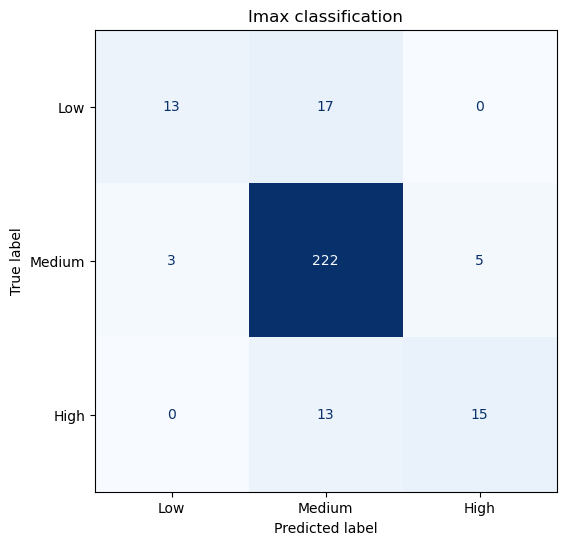

In [89]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_ids = [0, 1, 2]
class_names = ["Low", "Medium", "High"]

cm = confusion_matrix(
    y_class,
    y_pred_class,
    labels=class_ids
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Imax classification")
plt.show()

In [91]:
from sklearn.metrics import (
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

bal_acc = balanced_accuracy_score(y_class, y_pred_class)
precision = precision_score(y_class, y_pred_class, average="macro")
recall = recall_score(y_class, y_pred_class, average="macro")
f1 = f1_score(y_class, y_pred_class, average="macro")

print(f"Balanced Accuracy : {bal_acc:.3f}")
print(f"Macro Precision   : {precision:.3f}")
print(f"Macro Recall      : {recall:.3f}")
print(f"Macro F1-score    : {f1:.3f}")

Balanced Accuracy : 0.645
Macro Precision   : 0.814
Macro Recall      : 0.645
Macro F1-score    : 0.704


In [92]:
class_names = ["Low", "Medium", "High"]

print(
    classification_report(
        y_class,
        y_pred_class,
        target_names=class_names,
        digits=3
    )
)

              precision    recall  f1-score   support

         Low      0.812     0.433     0.565        30
      Medium      0.881     0.965     0.921       230
        High      0.750     0.536     0.625        28

    accuracy                          0.868       288
   macro avg      0.814     0.645     0.704       288
weighted avg      0.861     0.868     0.855       288



In [93]:
from sklearn.metrics import classification_report
import pandas as pd

class_names = ["Low", "Medium", "High"]

report = classification_report(
    y_class,
    y_pred_class,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).T
report_df = report_df.round(3)

report_df

,precision,recall,f1-score,support
Low,0.812,0.433,0.565,30.000
Medium,0.881,0.965,0.921,230.000
High,0.750,0.536,0.625,28.000
accuracy,0.868,0.868,0.868,0.868
macro avg,0.814,0.645,0.704,288.000
weighted avg,0.861,0.868,0.855,288.000
